In [3]:
import os
os.environ.pop("TF_USE_LEGACY_KERAS", None)


import librosa
%matplotlib inline
import matplotlib.pyplot as plt
import librosa.display
from IPython.display import Audio
import numpy as np
import tensorflow as tf
from matplotlib.pyplot import specgram
import pandas as pd
from sklearn.metrics import confusion_matrix
import IPython.display as ipd
import sys

data = pd.read_csv('../../data/featureEmodb.csv')

In [ ]:
import numpy as np
import random

np.random.seed(42)
random.seed(42)

In [4]:
data

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,gender,emo,speaker
0,-290.069550,120.892410,-44.022133,59.493820,-25.234184,24.166288,-20.102554,-3.104467,-3.912210,-8.433292,...,56.398769,0.009679,0.012519,-0.031646,0.024728,0.007912,0.001966,0,6,3
1,-274.512543,137.867325,-33.016861,49.305836,-7.529972,15.471715,-6.811347,-7.069037,-8.804790,-1.528063,...,53.806400,-0.001984,0.006133,-0.084608,0.109369,-0.025859,-0.003522,0,3,3
2,-225.866470,94.075874,-72.961555,41.311485,-27.577299,12.030844,-14.943604,-8.053857,-11.431667,-10.043902,...,54.852081,0.001015,-0.006297,-0.033966,-0.076824,0.011315,-0.001692,0,1,3
3,-273.849060,98.794968,-36.564865,36.316208,-22.404598,18.368185,-12.455775,-1.077722,-12.487121,-17.107168,...,58.313221,0.039030,-0.017753,-0.081100,-0.049775,0.015536,-0.007109,0,6,3
4,-252.887863,149.398911,-24.717367,45.297226,-0.930259,5.930630,0.473345,-0.681704,-12.864426,-9.714954,...,51.336941,0.008184,-0.018455,-0.020061,-0.058433,0.009487,0.034003,0,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,-255.980286,105.676674,-42.180950,75.896423,-23.686800,10.384299,-17.101816,-5.522916,-3.057154,-10.192598,...,56.598065,0.013773,-0.044897,0.036112,-0.103853,0.014030,0.004264,1,2,16
531,-246.298492,91.399818,-25.200518,57.381245,-6.517654,19.359470,-4.424452,-3.416811,2.381373,-6.032308,...,56.940429,0.022640,0.051658,0.111283,0.034628,0.032623,-0.023948,1,7,16
532,-287.566315,88.560669,-21.810999,60.376926,-0.650359,19.902147,-0.450192,2.266046,3.220632,-6.157897,...,56.867307,0.064417,0.045792,-0.014448,0.036817,-0.002728,-0.039342,1,7,16
533,-329.608124,67.631531,-87.368507,64.361099,-49.395180,-1.466112,-20.686680,-10.990952,-6.811410,-28.455215,...,53.589258,0.004312,0.004346,-0.046711,-0.008183,-0.011669,0.014701,1,1,16


In [5]:
import joblib

# Load the saved scaler
scaler = joblib.load("../scaler.pkl")

# Load the saved model
gender_model = tf.keras.models.load_model("../gender_classification_model.h5")

W0000 00:00:1762251725.896875 1942084 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [6]:
X_gender = data.iloc[:, :193].values
X_scaled = scaler.transform(X_gender)
gender_predictions = gender_model.predict(X_scaled)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [7]:
print(gender_predictions)

[[4.7407206e-03]
 [4.6157639e-04]
 [3.0386730e-03]
 [1.5244816e-03]
 [7.6849392e-04]
 [1.3095990e-03]
 [4.9879780e-04]
 [3.7963458e-04]
 [3.6571410e-01]
 [3.3532761e-03]
 [4.4729807e-03]
 [1.0930039e-03]
 [3.4315388e-03]
 [1.1107280e-03]
 [1.6056279e-03]
 [6.9866033e-04]
 [1.7894120e-03]
 [1.4085156e-03]
 [1.4026258e-03]
 [4.9669142e-03]
 [7.3762791e-04]
 [1.4017993e-03]
 [2.5455654e-03]
 [4.2543965e-04]
 [2.2492836e-04]
 [3.7402197e-04]
 [1.4532276e-03]
 [9.3619450e-04]
 [2.0258799e-03]
 [6.3483091e-04]
 [1.3890385e-03]
 [5.2728243e-03]
 [2.6253152e-03]
 [1.3338311e-03]
 [3.6826252e-03]
 [1.3467688e-03]
 [1.6858345e-03]
 [1.5898977e-03]
 [1.5722886e-03]
 [2.3024366e-03]
 [1.0618231e-03]
 [5.0643552e-03]
 [8.8569603e-04]
 [9.5791030e-01]
 [4.6573421e-03]
 [2.3879295e-03]
 [3.0233574e-03]
 [2.4481892e-04]
 [1.0407864e-03]
 [9.9979520e-01]
 [9.9941456e-01]
 [9.9919921e-01]
 [9.8543602e-01]
 [9.9929470e-01]
 [6.3582540e-01]
 [9.9987793e-01]
 [9.9837410e-01]
 [9.9931735e-01]
 [9.9904519e-0

In [8]:
male_rows = gender_predictions.flatten() >= 0.5  # 0 for Male, 1 for Female

df = data[male_rows]

print(f"Filtered dataset contains {df.shape[0]} female samples.")

Filtered dataset contains 304 female samples.


In [9]:
df.shape

(304, 196)

In [10]:
df

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,gender,emo,speaker
43,-276.010681,88.291550,-47.513107,47.787235,-31.076715,20.112261,-23.608137,-5.145355,-7.351628,-18.788027,...,57.022472,0.018160,-0.012818,0.059631,-0.026447,-0.011824,-0.023651,0,5,3
49,-242.296738,100.131287,-49.905891,39.019207,-28.569174,28.434782,-22.502106,-8.388103,-1.577434,-16.187185,...,56.029853,0.016974,0.017489,0.021310,-0.077259,-0.011524,-0.013297,1,5,8
50,-185.100357,102.095390,-32.449959,48.499172,-18.903458,17.655661,-11.422845,3.079878,-1.342817,-5.473735,...,56.943466,-0.006739,0.013350,0.045375,0.115081,0.011807,0.032250,1,6,8
51,-296.696777,111.588104,-15.979291,30.510899,-11.087157,21.032894,-8.265782,-8.720767,-4.711420,-11.372763,...,55.685641,-0.081280,0.044741,0.183663,-0.005616,-0.015490,0.079741,1,2,8
52,-317.351776,121.372276,-17.553547,53.506031,-19.536947,32.461872,-7.048652,2.529278,-0.955572,-5.793414,...,55.835431,-0.042968,-0.024235,-0.001901,-0.071230,0.004682,0.009318,1,3,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,-255.980286,105.676674,-42.180950,75.896423,-23.686800,10.384299,-17.101816,-5.522916,-3.057154,-10.192598,...,56.598065,0.013773,-0.044897,0.036112,-0.103853,0.014030,0.004264,1,2,16
531,-246.298492,91.399818,-25.200518,57.381245,-6.517654,19.359470,-4.424452,-3.416811,2.381373,-6.032308,...,56.940429,0.022640,0.051658,0.111283,0.034628,0.032623,-0.023948,1,7,16
532,-287.566315,88.560669,-21.810999,60.376926,-0.650359,19.902147,-0.450192,2.266046,3.220632,-6.157897,...,56.867307,0.064417,0.045792,-0.014448,0.036817,-0.002728,-0.039342,1,7,16
533,-329.608124,67.631531,-87.368507,64.361099,-49.395180,-1.466112,-20.686680,-10.990952,-6.811410,-28.455215,...,53.589258,0.004312,0.004346,-0.046711,-0.008183,-0.011669,0.014701,1,1,16


In [11]:
data.iloc[:,-3] == 0 #male

0       True
1       True
2       True
3       True
4       True
       ...  
530    False
531    False
532    False
533    False
534    False
Name: gender, Length: 535, dtype: bool

In [12]:
X_speaker = df.iloc[:, -1].copy()
X = df.iloc[:, :-3].copy()
y = df.iloc[:,-2].copy()

In [13]:
X

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
43,-276.010681,88.291550,-47.513107,47.787235,-31.076715,20.112261,-23.608137,-5.145355,-7.351628,-18.788027,...,16.205835,17.439993,17.160186,57.022472,0.018160,-0.012818,0.059631,-0.026447,-0.011824,-0.023651
49,-242.296738,100.131287,-49.905891,39.019207,-28.569174,28.434782,-22.502106,-8.388103,-1.577434,-16.187185,...,15.609642,18.692301,17.012600,56.029853,0.016974,0.017489,0.021310,-0.077259,-0.011524,-0.013297
50,-185.100357,102.095390,-32.449959,48.499172,-18.903458,17.655661,-11.422845,3.079878,-1.342817,-5.473735,...,14.983087,16.689537,17.606614,56.943466,-0.006739,0.013350,0.045375,0.115081,0.011807,0.032250
51,-296.696777,111.588104,-15.979291,30.510899,-11.087157,21.032894,-8.265782,-8.720767,-4.711420,-11.372763,...,16.867387,18.443066,17.613748,55.685641,-0.081280,0.044741,0.183663,-0.005616,-0.015490,0.079741
52,-317.351776,121.372276,-17.553547,53.506031,-19.536947,32.461872,-7.048652,2.529278,-0.955572,-5.793414,...,14.594819,17.331695,16.874626,55.835431,-0.042968,-0.024235,-0.001901,-0.071230,0.004682,0.009318
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,-255.980286,105.676674,-42.180950,75.896423,-23.686800,10.384299,-17.101816,-5.522916,-3.057154,-10.192598,...,16.838569,17.835524,19.693569,56.598065,0.013773,-0.044897,0.036112,-0.103853,0.014030,0.004264
531,-246.298492,91.399818,-25.200518,57.381245,-6.517654,19.359470,-4.424452,-3.416811,2.381373,-6.032308,...,15.286078,17.031323,18.757498,56.940429,0.022640,0.051658,0.111283,0.034628,0.032623,-0.023948
532,-287.566315,88.560669,-21.810999,60.376926,-0.650359,19.902147,-0.450192,2.266046,3.220632,-6.157897,...,14.402789,15.672307,17.590725,56.867307,0.064417,0.045792,-0.014448,0.036817,-0.002728,-0.039342
533,-329.608124,67.631531,-87.368507,64.361099,-49.395180,-1.466112,-20.686680,-10.990952,-6.811410,-28.455215,...,19.920409,19.619588,21.609127,53.589258,0.004312,0.004346,-0.046711,-0.008183,-0.011669,0.014701


In [14]:
y

43     5
49     5
50     6
51     2
52     3
      ..
530    2
531    7
532    7
533    1
534    1
Name: emo, Length: 304, dtype: int64

In [15]:
X_speaker

43      3
49      8
50      8
51      8
52      8
       ..
530    16
531    16
532    16
533    16
534    16
Name: speaker, Length: 304, dtype: int64

In [16]:
X.shape, y.shape

((304, 193), (304,))

In [17]:
from sklearn.utils import shuffle

X, y, X_speaker = shuffle(X, y, X_speaker, random_state=42)

In [18]:
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
y1 = to_categorical(lb.fit_transform(y))

In [19]:
y1

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(304, 7))

In [20]:
X.shape, y1.shape

((304, 193), (304, 7))

In [21]:
X2_speaker = X_speaker.copy().to_numpy()
X2=X.copy().to_numpy()
y2=y.copy().to_numpy()

In [22]:
X2.shape, X2_speaker.shape, y2.shape

((304, 193), (304,), (304,))

In [23]:
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.pyplot import specgram
import keras

from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding, Activation
from keras.layers import LSTM

from keras.utils import to_categorical
from keras.layers import Input, Flatten, Dropout#, Activation
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix
from keras.layers import BatchNormalization

def model1(input_shape1):
    model = Sequential()

    model.add(Conv1D(256, 5,padding='same',
                     input_shape=(input_shape1,1)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))


    model.add(Conv1D(256, 5,padding='same'))
    model.add(Activation('relu'))
    model.add(Dropout(0.1))

    model.add(BatchNormalization())

    model.add(MaxPooling1D(pool_size=(8)))
    model.add(Conv1D(256, 5,padding='same',))

    model.add(Activation('relu'))

    model.add(Conv1D(128, 5,padding='same',))
    model.add(Activation('relu'))
    model.add(Conv1D(128, 5,padding='same',))
    model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(Dropout(0.2))

    model.add(Flatten())
    model.add(Dropout(0.2))
    model.add(Dense(7))
    model.add(BatchNormalization())
    model.add(Activation('softmax'))

    return model

In [24]:
import random, numpy as np
from keras import optimizers
kfold=5
def create_index(kfold, size):
    a = []
    for i in range(size):
        a.append(i)
    random.shuffle(a)
    arr = np.array(a)
    return arr.reshape(kfold, size//kfold)

In [25]:
X3=pd.DataFrame(X2)
X3

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
0,-309.687683,92.159103,-38.313023,52.110058,-23.497505,30.036774,-21.611717,-4.584645,-7.509318,-10.200588,...,15.226097,17.280133,16.569275,57.889888,-0.007681,-0.027543,0.068826,0.018333,-0.022740,-0.012447
1,-252.027237,106.033699,-44.029644,40.377258,-14.988658,2.006388,-17.424500,-2.945374,-15.075464,-11.314260,...,17.497797,17.686796,17.607354,56.244315,-0.040669,-0.025850,-0.041106,0.084050,-0.001283,-0.012524
2,-247.501389,120.397377,-30.061649,65.334114,-19.743235,31.171110,0.448775,4.027779,-4.429404,-15.082378,...,13.274123,15.821154,17.298965,54.716436,-0.023122,0.019284,-0.073646,-0.076861,-0.022624,0.011674
3,-301.953918,54.059975,-68.077881,41.408878,-32.196445,-2.269524,-18.940617,-8.426182,-2.283169,-19.595749,...,19.382595,18.840025,20.926138,55.187727,-0.016229,0.009055,0.007453,0.036811,-0.014775,-0.004566
4,-276.028046,67.800751,-99.479965,43.298203,-33.114784,1.550587,-17.933628,-15.602693,-1.432890,-10.395594,...,21.331411,20.634607,21.656001,53.637967,0.029671,0.014084,0.109055,-0.085618,0.020301,-0.010166
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,-276.581482,91.643784,-50.315346,47.790154,-37.516369,7.750670,-18.004366,-10.279112,-5.893856,-19.520216,...,17.616242,17.942695,18.274429,55.062009,0.022938,0.024144,0.052083,-0.011187,-0.000132,0.000828
300,-265.422180,102.525887,-27.400837,42.237522,-21.106188,8.025195,-16.511087,-8.478481,-4.688387,-5.316031,...,15.138105,16.521220,17.578036,57.032659,0.004634,0.015101,0.007069,0.026312,0.002874,0.001108
301,-222.875443,114.546761,-32.756065,65.297585,-15.618677,26.252253,-26.420240,-5.221539,-3.731523,-1.713276,...,14.305739,16.527830,16.643373,56.841507,0.013340,-0.014222,0.046376,0.016262,-0.015717,-0.005863
302,-238.760941,85.362534,-45.111145,67.797318,-14.177221,12.407270,-31.929052,-11.875333,-9.117326,-19.169992,...,16.171358,18.212507,18.715295,56.831077,0.001952,-0.013217,-0.016857,-0.064448,0.020023,0.025306


In [26]:
X3_speaker = pd.DataFrame(X2_speaker)
X3_speaker

,0
0,14
1,13
2,13
3,16
4,9
...,...
299,14
300,9
301,13
302,16


In [27]:
speakers = X_speaker.unique()
speakers

array([14, 13, 16,  9,  8, 15,  3, 10])

In [28]:
X3_col = X3_speaker.rename(columns={0: 'speaker'})
X3_col

,speaker
0,14
1,13
2,13
3,16
4,9
...,...
299,14
300,9
301,13
302,16


In [29]:
X_combined = pd.concat([X3, X3_col], axis=1)
X_combined

,0,1,2,3,4,5,6,7,8,9,...,184,185,186,187,188,189,190,191,192,speaker
0,-309.687683,92.159103,-38.313023,52.110058,-23.497505,30.036774,-21.611717,-4.584645,-7.509318,-10.200588,...,17.280133,16.569275,57.889888,-0.007681,-0.027543,0.068826,0.018333,-0.022740,-0.012447,14
1,-252.027237,106.033699,-44.029644,40.377258,-14.988658,2.006388,-17.424500,-2.945374,-15.075464,-11.314260,...,17.686796,17.607354,56.244315,-0.040669,-0.025850,-0.041106,0.084050,-0.001283,-0.012524,13
2,-247.501389,120.397377,-30.061649,65.334114,-19.743235,31.171110,0.448775,4.027779,-4.429404,-15.082378,...,15.821154,17.298965,54.716436,-0.023122,0.019284,-0.073646,-0.076861,-0.022624,0.011674,13
3,-301.953918,54.059975,-68.077881,41.408878,-32.196445,-2.269524,-18.940617,-8.426182,-2.283169,-19.595749,...,18.840025,20.926138,55.187727,-0.016229,0.009055,0.007453,0.036811,-0.014775,-0.004566,16
4,-276.028046,67.800751,-99.479965,43.298203,-33.114784,1.550587,-17.933628,-15.602693,-1.432890,-10.395594,...,20.634607,21.656001,53.637967,0.029671,0.014084,0.109055,-0.085618,0.020301,-0.010166,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,-276.581482,91.643784,-50.315346,47.790154,-37.516369,7.750670,-18.004366,-10.279112,-5.893856,-19.520216,...,17.942695,18.274429,55.062009,0.022938,0.024144,0.052083,-0.011187,-0.000132,0.000828,14
300,-265.422180,102.525887,-27.400837,42.237522,-21.106188,8.025195,-16.511087,-8.478481,-4.688387,-5.316031,...,16.521220,17.578036,57.032659,0.004634,0.015101,0.007069,0.026312,0.002874,0.001108,9
301,-222.875443,114.546761,-32.756065,65.297585,-15.618677,26.252253,-26.420240,-5.221539,-3.731523,-1.713276,...,16.527830,16.643373,56.841507,0.013340,-0.014222,0.046376,0.016262,-0.015717,-0.005863,13
302,-238.760941,85.362534,-45.111145,67.797318,-14.177221,12.407270,-31.929052,-11.875333,-9.117326,-19.169992,...,18.212507,18.715295,56.831077,0.001952,-0.013217,-0.016857,-0.064448,0.020023,0.025306,16


In [30]:
# Get top 5 speakers with the most data

speaker_counts = X_combined['speaker'].value_counts()
selected_speakers = speaker_counts.head(5).index.to_numpy()

print("Selected speakers:", selected_speakers)

Selected speakers: [14 16 13  8  9]


In [31]:
from skfeature.function.similarity_based import fisher_score
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

hist=[]
scores=[]
totalsize=300
num_fea=125
a=create_index(kfold,totalsize)

for i in range (kfold):
    model_name = 'Model_'+str(i)
    savedir='emodb_speaker_female_193'
    model_path = os.path.join(savedir, (model_name+'.h5'))

    # Choose one test speaker from selected_speakers
    test_speaker = selected_speakers[i]

    # Use only speakers not in selected_speakers as training
    train_speakers = np.setdiff1d(speakers, [test_speaker])

    print(f"\n===== Fold {i} =====")
    print("Test speaker:", test_speaker)
    print("Train speakers:", train_speakers)

    # Get the indices for test and train
    train_indices = X_combined[X_combined['speaker'].isin(train_speakers)].index
    test_indices = X_combined[X_combined['speaker'] == test_speaker].index


    # Sanity check for overlaps
    overlap_indices = np.intersect1d(train_indices, test_indices)
    if len(overlap_indices) > 0:
        print(f"Overlap found in fold {i}! Overlapping indices: {overlap_indices}")
    else:
        print(f"No overlap in fold {i}.")

    
    # Prepare training and testing sets
    X_train = X_combined.drop(columns=['speaker']).iloc[train_indices, :]
    y_train = y1[train_indices, :]

    X_test = X_combined.drop(columns=['speaker']).iloc[test_indices, :]
    y_test = y1[test_indices, :]


    # Scale separately
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # CNN input shape adjustment
    x_traincnn = np.expand_dims(X_train_scaled, axis=2)
    x_testcnn = np.expand_dims(X_test_scaled, axis=2)

    m1= model1(x_traincnn.shape[1])
    opt = tf.keras.optimizers.RMSprop(learning_rate=0.00005, decay=1e-6)
    m1.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_accuracy', patience=700, restore_best_weights=True)

    # Train
    history = m1.fit(
        x_traincnn, y_train,
        batch_size=32, epochs=700,
        validation_data=(x_testcnn, y_test),
        callbacks=[early_stopping],
        verbose=1
    )
    hist.append(history)

    # Evaluate
    score_eval = m1.evaluate(x_testcnn, y_test, verbose=0)
    scores.append(score_eval)
    print(f"Fold {i} Test Accuracy: {score_eval[1]:.4f}")

    # Save data for reproducibility
    np.save(os.path.join(savedir, f"X_train_fold{i}.npy"), x_traincnn)
    np.save(os.path.join(savedir, f"y_train_fold{i}.npy"), y_train)

    np.save(os.path.join(savedir, f"X_test_fold{i}.npy"), x_testcnn)
    np.save(os.path.join(savedir, f"y_test_fold{i}.npy"), y_test)

    # Save model
    model_name = f"Model_{i}.h5"
    model_path = os.path.join(savedir, model_name)
    model_json = m1.to_json()
    with open(os.path.join(savedir, f"Model_{i}.json"), "w") as json_file:
        json_file.write(model_json)
    m1.save(model_path)


print("\n===== Cross-validation results =====")
for i, sc in enumerate(scores):
    print(f"Fold {i}: Loss={sc[0]:.4f}, Accuracy={sc[1]:.4f}")
print(f"\nAverage accuracy: {np.mean([s[1] for s in scores]):.4f}")


===== Fold 0 =====
Test speaker: 14
Train speakers: [ 3  8  9 10 13 15 16]
No overlap in fold 0.
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.2255 - loss: 2.0362 - val_accuracy: 0.3043 - val_loss: 1.9271
Epoch 2/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4851 - loss: 1.4361 - val_accuracy: 0.3043 - val_loss: 1.9312
Epoch 3/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5532 - loss: 1.2678 - val_accuracy: 0.2174 - val_loss: 1.9386
Epoch 4/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6596 - loss: 1.1523 - val_accuracy: 0.1594 - val_loss: 1.9465
Epoch 5/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6936 - loss: 1.0791 - val_accuracy: 0.1594 - val_loss: 1.9581
Epoch 6/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7149 - loss: 1.0283 - val_accuracy: 0.1739 - val_loss: 1.9660
Epoch 7/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7872 - loss: 0.9554 - val_accuracy: 0.1739 - val_loss: 1.9728
Epoch 8/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8043 - loss: 0.9200 - val_accuracy: 0.1739 - val_loss: 1.9771
Epoc

Fold 0 Test Accuracy: 0.7971

===== Fold 1 =====
Test speaker: 16
Train speakers: [ 3  8  9 10 13 14 15]
No overlap in fold 1.


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.2567 - loss: 1.9533 - val_accuracy: 0.2093 - val_loss: 1.9319
Epoch 2/700
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4789 - loss: 1.4591 - val_accuracy: 0.1860 - val_loss: 1.9062
Epoch 3/700
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6207 - loss: 1.3010 - val_accuracy: 0.2791 - val_loss: 1.8873
Epoch 4/700
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6705 - loss: 1.1578 - val_accuracy: 0.3023 - val_loss: 1.8742
Epoch 5/700
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6897 - loss: 1.0919 - val_accuracy: 0.2558 - val_loss: 1.8641
Epoch 6/700
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7739 - loss: 1.0151 - val_accuracy: 0.2558 - val_loss: 1.8572
Epoch 7/700
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7548 - loss: 0.9577 - val_accuracy: 0.2558 - val_loss: 1.8474
Epoch 8/700
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7778 - loss: 0.9588 - val_accuracy: 0.2558 - val_loss: 1.8359
Epoc

Fold 4 Test Accuracy: 0.7209

===== Cross-validation results =====
Fold 0: Loss=1.1216, Accuracy=0.7971
Fold 1: Loss=1.3417, Accuracy=0.6232
Fold 2: Loss=1.3016, Accuracy=0.6885
Fold 3: Loss=1.2958, Accuracy=0.7241
Fold 4: Loss=1.3866, Accuracy=0.7209

Average accuracy: 0.7108


In [1]:
import numpy as np
import keras
from keras.models import model_from_json
from sklearn.metrics import confusion_matrix

savedir = 'emodb_speaker_female_193'
num_folds = 5 
opt = keras.optimizers.RMSprop(learning_rate=0.00001, decay=1e-6)

accuracies = []
conf_matrices = []

for i in range(num_folds):
    model_name = f"Model_{i}"

    with open(f"{savedir}/{model_name}.json", "r") as json_file:
        loaded_model = model_from_json(json_file.read())
    loaded_model.load_weights(f"{savedir}/{model_name}.h5")

    loaded_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    X_test = np.load(f"{savedir}/X_test_fold{i}.npy")
    y_test = np.load(f"{savedir}/y_test_fold{i}.npy")

    score = loaded_model.evaluate(X_test, y_test, verbose=0)
    acc = score[1] * 100
    accuracies.append(acc)

    y_pred = loaded_model.predict(X_test, verbose=0)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true_labels = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true_labels, y_pred_labels)
    conf_matrices.append(cm)

    print(f"Fold {i}: Accuracy = {acc:.2f}%")

# array: (num_folds, num_classes, num_classes)
conf_matrices = np.array(conf_matrices)

print("\nMean Accuracy: %.2f%%" % np.mean(accuracies))
print("SD Accuracy: %.2f" % np.std(accuracies))

n = num_folds
ci95 = 1.96 * (np.std(accuracies) / np.sqrt(n))
print("95%% CI: ± %.2f" % ci95)


2025-11-06 15:50:06.307551: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-06 15:50:06.338406: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-06 15:50:07.033946: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-

Fold 0: Accuracy = 79.71%
Fold 1: Accuracy = 62.32%
Fold 2: Accuracy = 68.85%
Fold 3: Accuracy = 72.41%
Fold 4: Accuracy = 72.09%

Mean Accuracy: 71.08%
SD Accuracy: 5.64
95% CI: ± 4.94


/tmp/ipykernel_64856/57385105.py:5: RuntimeWarning: invalid value encountered in divide
  conf_matrices_percent = conf_matrices / conf_matrices.sum(axis=2, keepdims=True) * 100


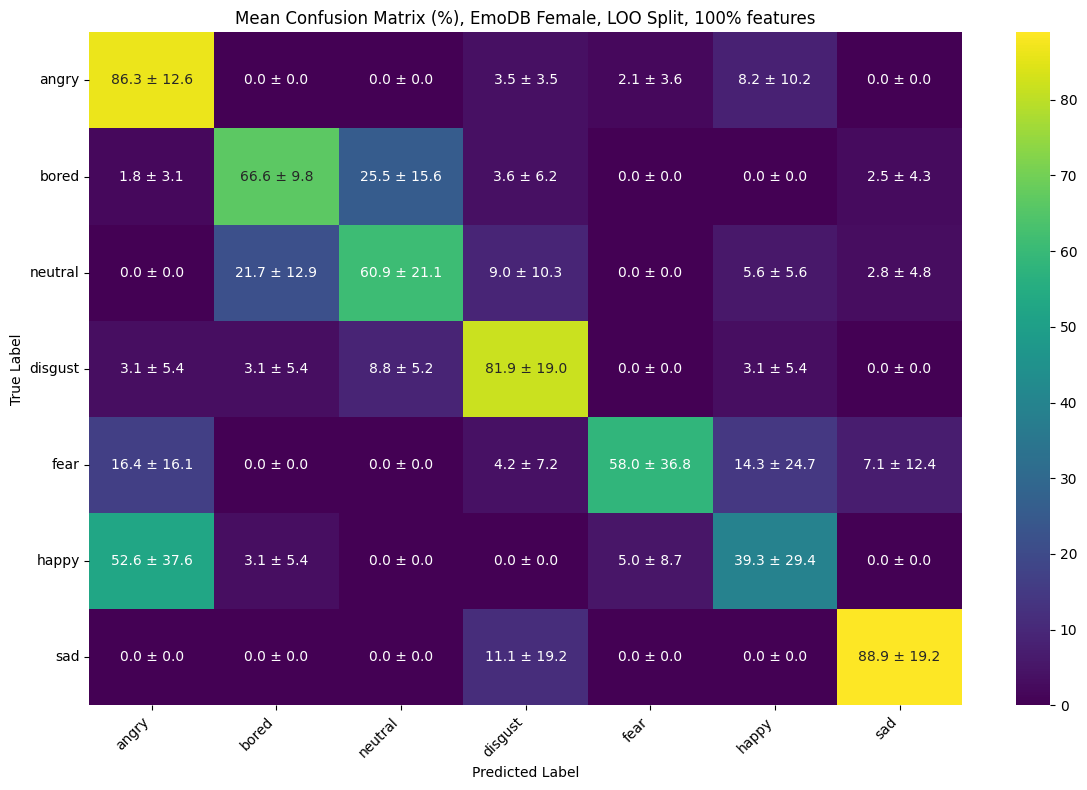

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

conf_matrices_percent = conf_matrices / conf_matrices.sum(axis=2, keepdims=True) * 100

valid_folds = conf_matrices.sum(axis=2)[:, 3] > 0  # index 3 = disgust
conf_matrices_percent = conf_matrices_percent[valid_folds]

np.save('cm_emodb_speaker_female_193.npy', conf_matrices_percent)


mean_cm = np.mean(conf_matrices_percent, axis=0)
std_cm = np.std(conf_matrices_percent, axis=0)

labels = np.empty(mean_cm.shape, dtype=object)
for i in range(mean_cm.shape[0]):
    for j in range(mean_cm.shape[1]):
        labels[i, j] = f"{mean_cm[i, j]:.1f} ± {std_cm[i, j]:.1f}"

listik = ['angry', 'bored', 'neutral', 'disgust', 'fear', 'happy', 'sad']

# Plot
plt.figure(figsize=(12,8))
ax = sns.heatmap(mean_cm, annot=labels, fmt="", cmap="viridis", cbar=True)

ax.set_xticks(np.arange(len(listik)) + 0.5)
ax.set_yticks(np.arange(len(listik)) + 0.5)
ax.set_xticklabels(listik, rotation=45, ha="right")
ax.set_yticklabels(listik, rotation=0)

plt.title("Mean Confusion Matrix (%), EmoDB Female, LOO Split, 100% features")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()
